# Import Library

In [11]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler

# Import Dataset

In [12]:
import pandas as pd

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# Nama kolom sesuai deskripsi dataset
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
    'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Memuat data dari URL
data = pd.read_csv(url, sep=',', header=None, names=columns, na_values='?')

# Konversi kolom ca dan thal ke numerik
data['ca'] = pd.to_numeric(data['ca'], errors='coerce')
data['thal'] = pd.to_numeric(data['thal'], errors='coerce')

# Menangani missing values
data = data.dropna()

# Menyesuaikan target: Di dataset UCI, 0 = sehat, 1-4 = sakit.
# Kita ubah menjadi biner (0 dan 1) agar sesuai dengan sisa kode Anda.
data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)

print("Data berhasil dimuat dan disesuaikan menjadi klasifikasi biner.")
display(data.head())

Data berhasil dimuat dan disesuaikan menjadi klasifikasi biner.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


https://archive.ics.uci.edu/ml/datasets/Heart+Disease

# Menampilkan beberapa data paling atas

In [13]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Data Deskripsi:**

age - Umur dalam setahun

sex - (1 = Pria || 0 = Wanita)

cp - chest pain type (jenis nyeri dada)
-- 1: typical angina
-- 2: atypical angina
-- 3: non-anginal pain
-- 4: asymptomatic

trestbps - resting blood pressure (dalam MM Hg(raksa) saat masuk ke rumah sakit)
Info Tambahan:
Tekanan darah optimal biasanya didefinisikan sebagai sistolik 120 mm Hg.
diastolik lebih dari 80 mm Hg - yang merupakan tekanan saat jantung rileks.
Dan untuk detak jantung istirahat, targetnya adalah antara 60 dan 100 detak per menit

chol - serum kolestoral dalam mg/dl

fbs - (fasting blood sugar > 120 mg/dL) (1 = benar || 0 = salah)
Info Tambahan:
Kadar gula darah kurang dari 100 mg/dL adalah normal. Kadar gula darah dari 100 hingga 125 mg / dL dianggap pradiabetes. Jika 126 mg / dL atau lebih tinggi pada dua tes terpisah menderita diabetes

restecg - resting electrocardiographic results (pemeriksaan yang rutin dilakukan untuk mendeteksi berbagai kelainan pada jantung dengan cara mengetahui aktivitas kelistrikan jantung)
-- 0: normal
-- 1: memiliki kelainan gelombang ST-T
-- 2: menunjukkan kemungkinan atau pasti hipertrofi ventrikel kiri (pembesaran bilik kiri jantung)

thalach - maximum heart rate achieved

exang - exercise induced angina (1 = yes; 0 = no) merupakan keluhan umum pasien jantung

oldpeak - Depresi ST disebabkan oleh olahraga relatif terhadap istirahat

slope - kemiringan segmen pada latihan ST puncak (0 = upsloping; 1 = flat; 2 = downsloping)

ca - jumlah pembuluh darah utama (0-3) diwarnai dengan fluoroskopi

thal - 3 = normal; 6 = fixed defect; 7 = reversable defect

target - Memiliki Penyakit atau Tidak (1=yes, 0=no)

# Mengecek Data Kosong

In [14]:
print(data.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


# Cek Statistika Data

In [15]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


### One-Hot Encoding for Categorical Features

Some features in the dataset are categorical (e.g., `cp`, `restecg`, `slope`, `ca`, `thal`) but are currently treated as numerical. For many machine learning models, especially linear models and SVMs, it's often beneficial to convert these into one-hot encoded features. This prevents the model from assuming an ordinal relationship or numerical magnitude between categories.

First, let's examine the unique values in `ca` and `thal` more closely, as their descriptions and `describe()` outputs had slight inconsistencies.

In [16]:
print('Unique values in ca:', data['ca'].unique())
print('Unique values in thal:', data['thal'].unique())

# Based on the unique values, we will proceed with one-hot encoding.

Unique values in ca: [0. 3. 2. 1.]
Unique values in thal: [6. 3. 7.]


Now, let's apply one-hot encoding to the identified categorical columns.

**Note**: After running this cell, you will need to re-run the `Train Test Split`, `Normalisasi Data`, and all `Predictions and Evaluation` cells to apply these changes to your models.

In [17]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Create a copy and convert to category types
data_encoded = data.copy()
for col in categorical_cols:
    data_encoded[col] = data_encoded[col].astype('category')

# Apply one-hot encoding
data_encoded = pd.get_dummies(data_encoded, columns=categorical_cols, drop_first=True)

print("Data after one-hot encoding:")
display(data_encoded.head())

# Update X and y for the following cells
X = data_encoded.drop('target', axis=1).values
y = data_encoded['target'].values

print(f"\nShape of X after encoding: {X.shape}")

Data after one-hot encoding:


,age,trestbps,chol,thalach,oldpeak,target,sex_1.0,cp_2.0,cp_3.0,cp_4.0,...,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
0,63.0,145.0,233.0,150.0,2.3,0,True,False,False,False,...,False,True,False,False,True,False,False,False,True,False
1,67.0,160.0,286.0,108.0,1.5,1,True,False,False,True,...,False,True,True,True,False,False,False,True,False,False
2,67.0,120.0,229.0,129.0,2.6,1,True,False,False,True,...,False,True,True,True,False,False,True,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,41.0,130.0,204.0,172.0,1.4,0,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False



Shape of X after encoding: (297, 20)


# Jumlah Data Target (1:Terkena Penyakit || 0:Tidak Terkena Penyakit)

In [18]:
data['target'].value_counts()

,count
target,
0,160
1,137


# Exploratory Data Analysis
**Visualisasi Data**

/tmp/ipykernel_2742/609888748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x=sns.countplot(x="target", data=data, palette="rocket")


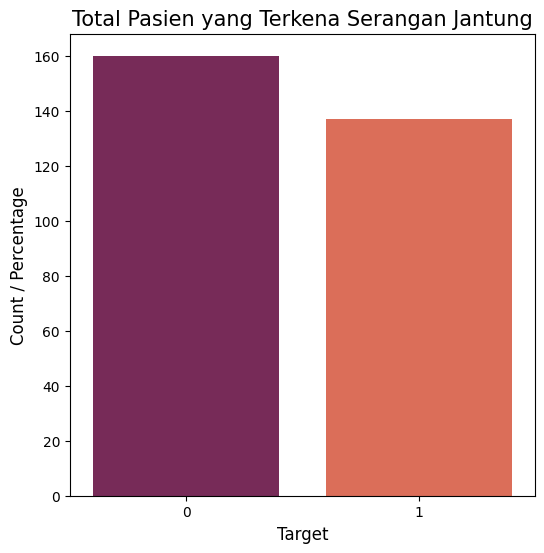

In [19]:
x = plt.subplots(figsize=(6,6))
x=sns.countplot(x="target", data=data, palette="rocket")
x.set_xlabel ("Target",fontsize=12)
x.set_ylabel ("Count / Percentage",fontsize=12)
x.set_title("Total Pasien yang Terkena Serangan Jantung", fontsize=15)
sns.set_style("whitegrid")
plt.show()

In [20]:
TidakKenaPenyakit = len(data[data.target == 0])
TerkenaPenyakit = len(data[data.target == 1])
print("Persentasi Pasien yang tidak terkena Penyakit Jantung: {:.2f}%".format((TidakKenaPenyakit / (len(data.target))*100)))
print("Persentasi Pasien yang terkena Penyakit Jantung: {:.2f}%".format((TerkenaPenyakit / (len(data.target))*100)))

Persentasi Pasien yang tidak terkena Penyakit Jantung: 53.87%
Persentasi Pasien yang terkena Penyakit Jantung: 46.13%


Didapatkan Hasil Total Pasien yang Terkena Penyakit Jantung >160 orang dan persentasi nya 54.46%, dibandingkan pasien yang tidak terkena penyakit jantung <140 dan persentasi nya 45.54%.

/tmp/ipykernel_2742/810038550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  x=sns.countplot(x="sex", data=data, palette="magma")


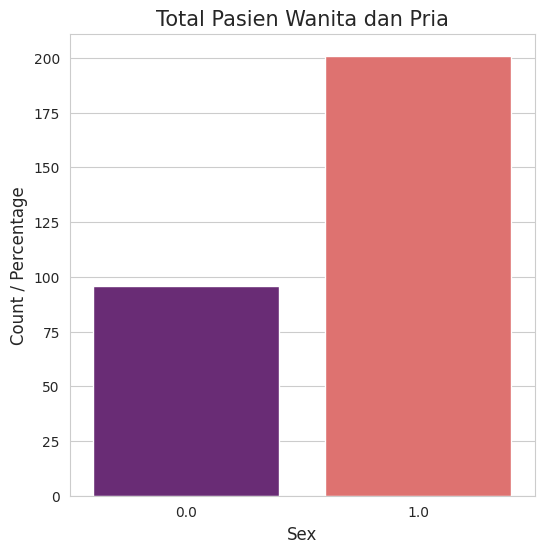

In [21]:
x=plt.subplots(figsize=(6,6))
x=sns.countplot(x="sex", data=data, palette="magma")
x.set_xlabel ("Sex",fontsize=12)
x.set_ylabel ("Count / Percentage",fontsize=12)
x.set_title("Total Pasien Wanita dan Pria", fontsize=15)
sns.set_style("whitegrid")
plt.show()

In [22]:
Wanita = len(data[data.sex == 0])
Pria = len(data[data.sex == 1])
print("Persentasi Pasien Wanita: {:.2f}%".format((Wanita / (len(data.sex))*100)))
print("Persentasi Pasien Pria: {:.2f}%".format((Pria / (len(data.sex))*100)))

Persentasi Pasien Wanita: 32.32%
Persentasi Pasien Pria: 67.68%


Didaptkan Hasil Total Pasien PRIA >200 pria dan persentasi nya 68.32%, dibandingkan pasien Wanita <100 dan persentasi nya 31.68%.

**Sekarang kita hubungkan dan visualisasikan antara sex dan target**

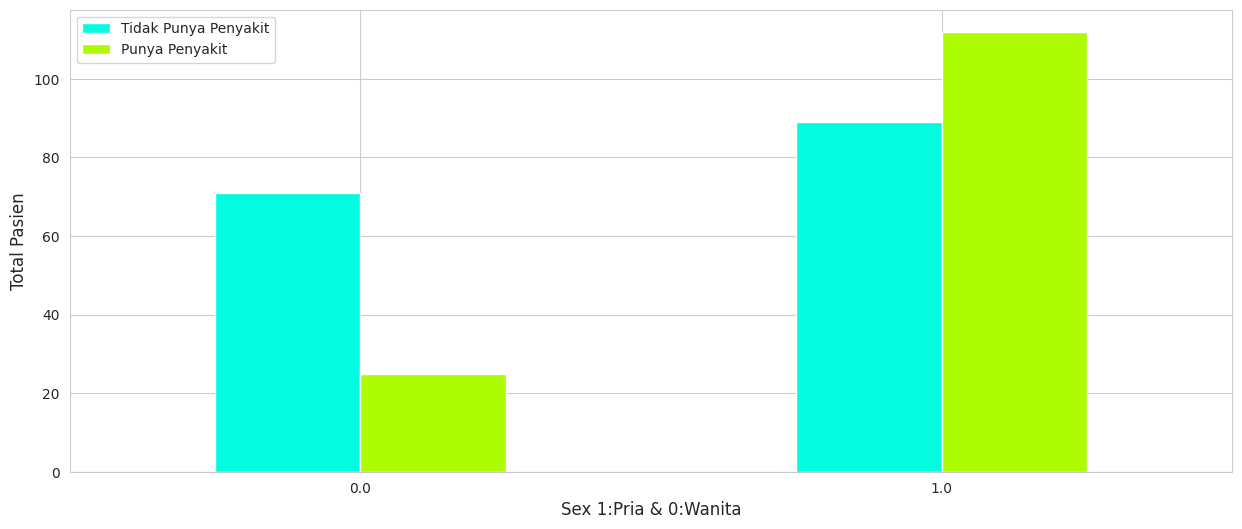

In [23]:
pd.crosstab(data.sex,data.target).plot(color=['#03fcdf','#adfc03'],kind="bar",figsize=(15,6))
plt.xlabel('Sex 1:Pria & 0:Wanita',fontsize=12)
plt.ylabel('Total Pasien',fontsize=12)
plt.xticks(rotation = 0)
plt.legend(["Tidak Punya Penyakit", "Punya Penyakit"])
plt.show()

**Visualisasi data umur untuk mengetahui meannya**

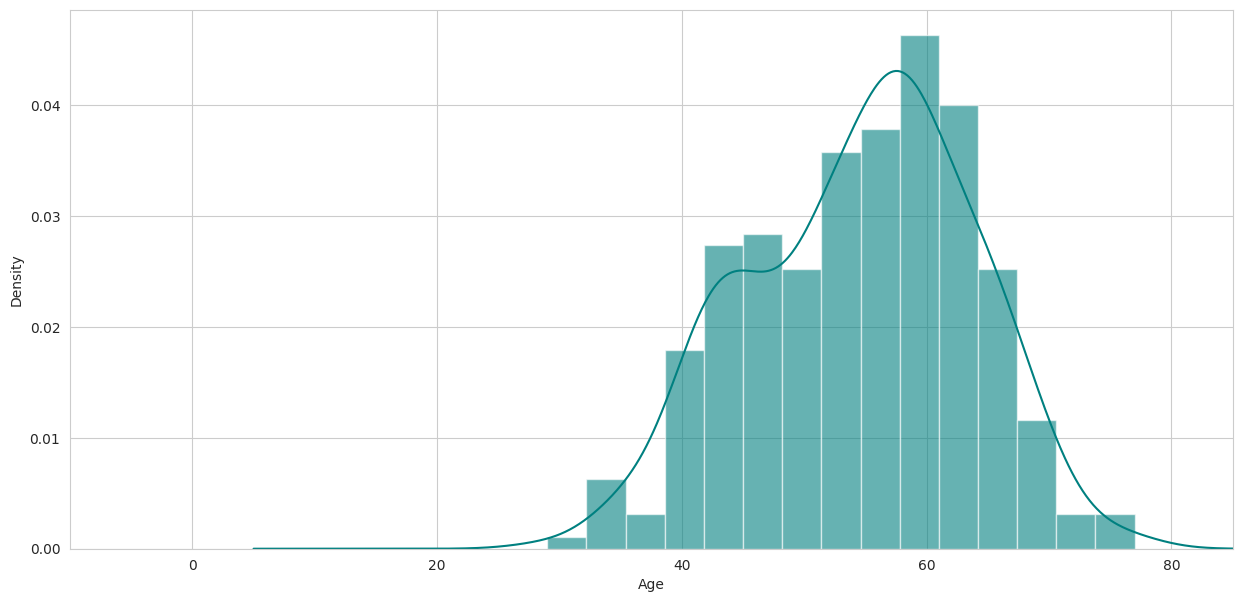

In [24]:
plt.subplots(figsize = (15,7))
ax = data["age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
data["age"].plot(kind='density', color='teal')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

In [25]:
print('mean "Age" adalah %d' %(data["age"].mean(skipna=True)))
print('median "Age" adalah %d' %(data["age"].median(skipna=True)))

mean "Age" adalah 54
median "Age" adalah 56


**Visualisasi Data Hubungan antara age dan target (Memiliki Penyakit atau Tidak (1=yes, 0=no)**

/tmp/ipykernel_2742/753548824.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['target'] == 0]['age'], bins = 30, kde = False,  color = 'red',label = 'Tidak ada penyakit Jantung = 0')
/tmp/ipykernel_2742/753548824.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[data['target

Text(0, 0.5, 'Banyak Pasien')

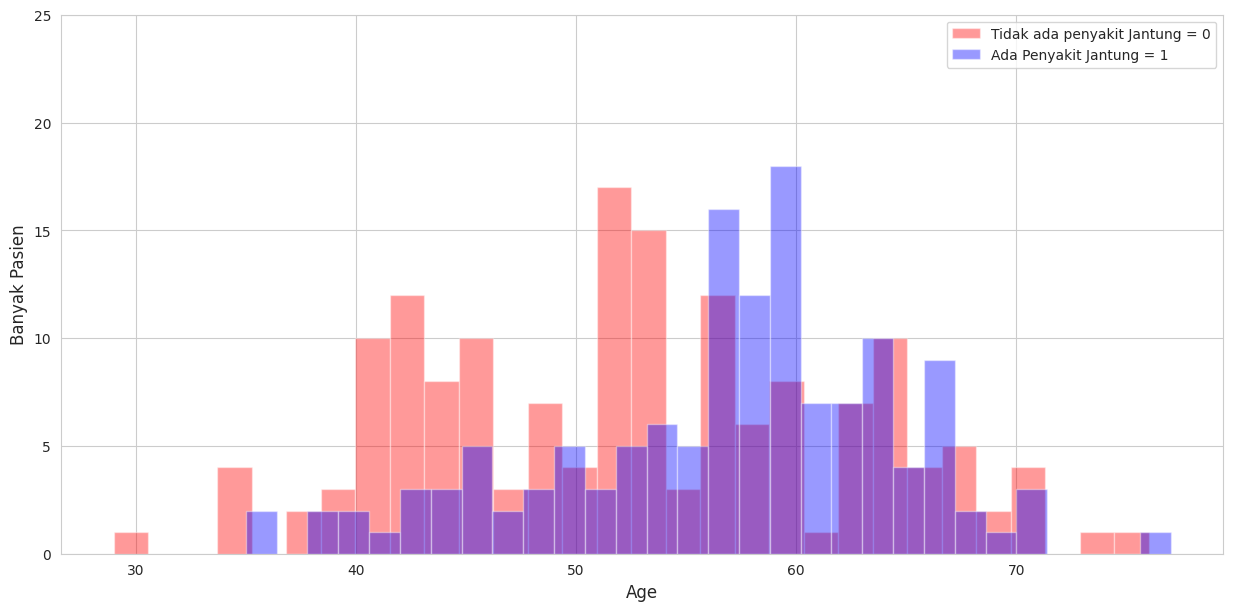

In [26]:
plt.subplots(figsize = (15,7))
sns.distplot(data[data['target'] == 0]['age'], bins = 30, kde = False,  color = 'red',label = 'Tidak ada penyakit Jantung = 0')
sns.distplot(data[data['target'] == 1]['age'], bins = 30, kde = False,  color = 'blue',label = 'Ada Penyakit Jantung = 1')
plt.ylim(0,25)
plt.legend()
plt.xlabel('Age', fontsize = 12)
plt.ylabel('Banyak Pasien', fontsize = 12)

**Visualisasi Data Hubungan antara thalach-maximum heart archived, oldpeak, exang(ada keluhan angina atau tidak) dan target (Memiliki Penyakit atau Tidak (1=yes, 0=no))**

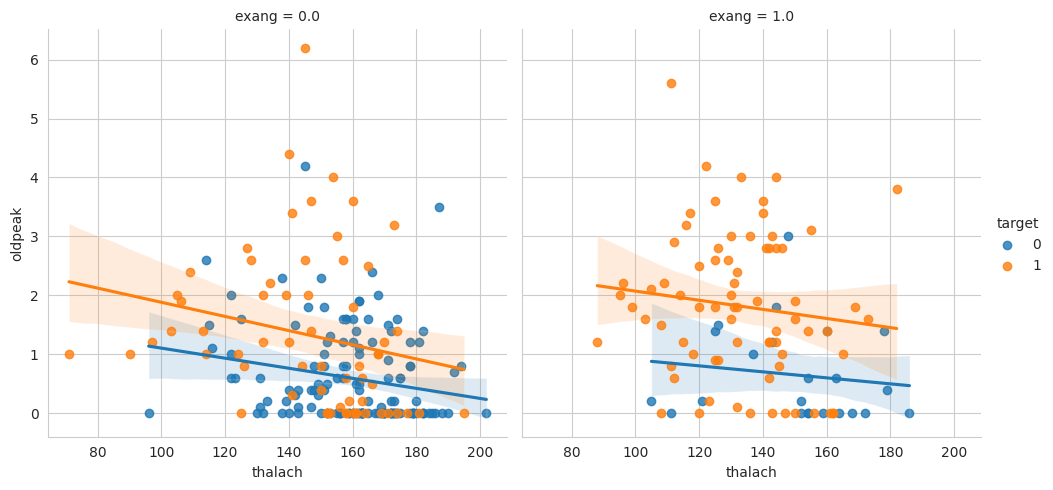

In [27]:
sns.lmplot(x ='thalach', y ='oldpeak', col ='exang', hue ='target', data=data)

**Visualisasi Data Hubungan antara age, thalach-Maximum Heart Archived dan target (Memiliki Penyakit atau Tidak (1=yes, 0=no))**

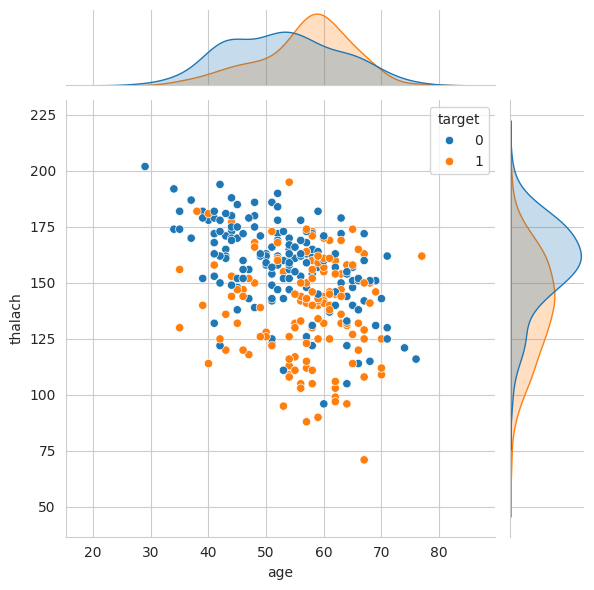

In [28]:
sns.jointplot(x = data['age'], y = data['thalach'], hue = data['target'], data = data)

**Banyak pasien yang terkena Penyakit jantung berdasarkan Kemiringan Segmen pada Latihan puncak ST**

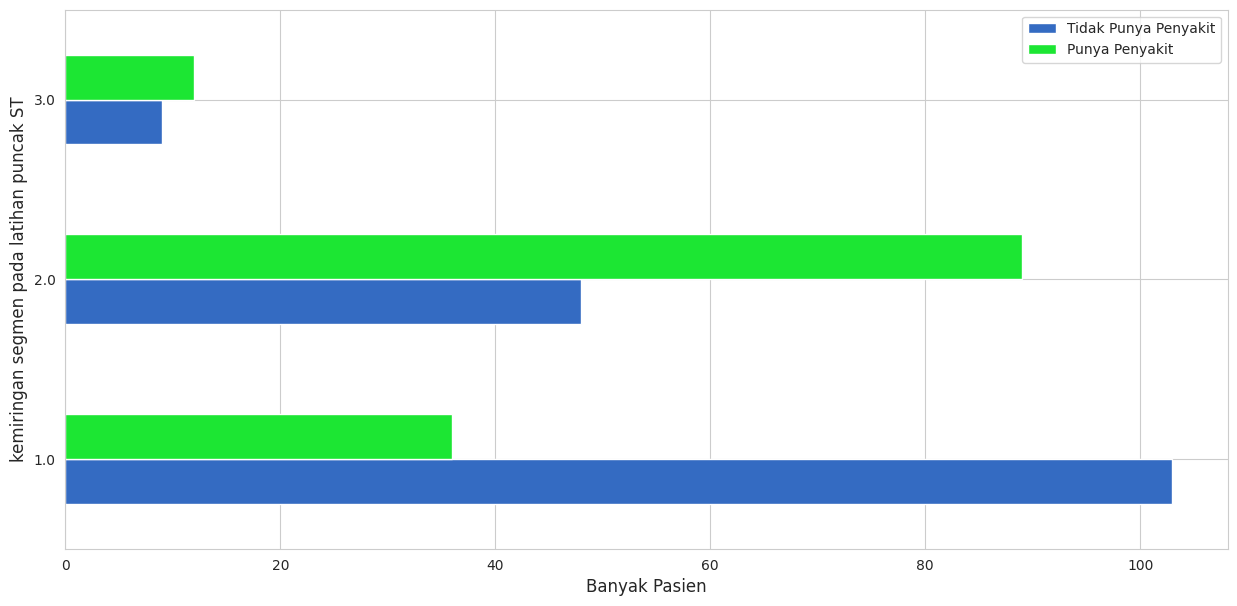

In [29]:
pd.crosstab(data.slope,data.target).plot(color=['#346bc2','#1ce633'],kind="barh",figsize=(15,7))
plt.ylabel('kemiringan segmen pada latihan puncak ST',fontsize=12)
plt.xlabel('Banyak Pasien',fontsize=12)
plt.xticks(rotation = 0)
plt.legend(["Tidak Punya Penyakit", "Punya Penyakit"])
plt.show()

slope - kemiringan segmen pada latihan ST puncak (0 = upsloping; 1 = flat; 2 = downsloping)

**Banyak pasien yang terkena Penyakit Jantung berdasarkan hasil resting electrocardiographic**

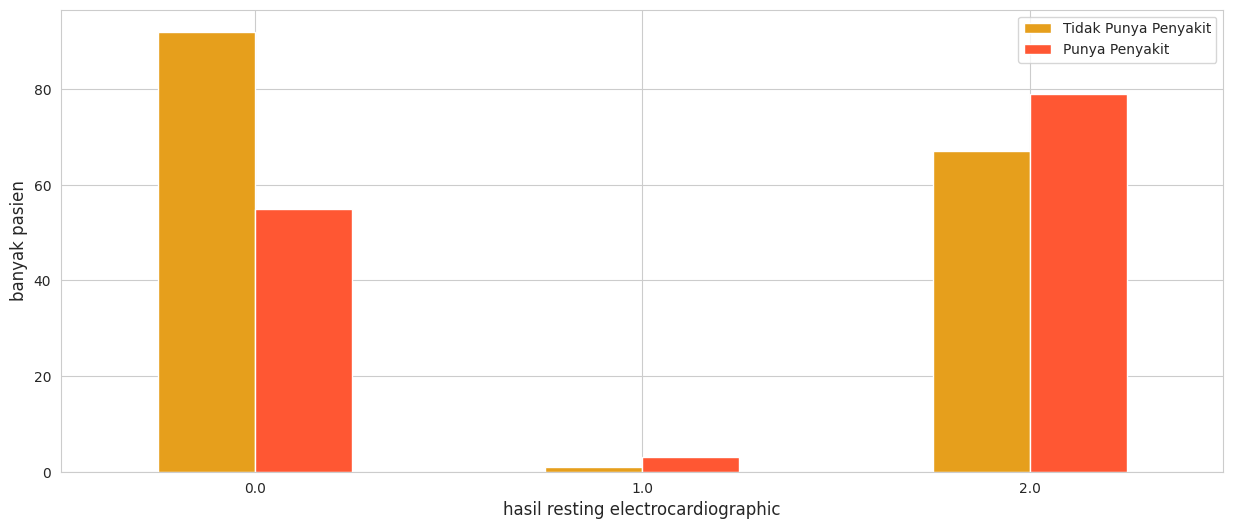

In [30]:
pd.crosstab(data.restecg,data.target).plot(color=['#e69f1c','#FF5733'],kind="bar",figsize=(15,6))
plt.xlabel('hasil resting electrocardiographic',fontsize=12)
plt.ylabel('banyak pasien',fontsize=12)
plt.xticks(rotation = 0)
plt.legend(["Tidak Punya Penyakit", "Punya Penyakit"])
plt.show()

0: normal -- 1: memiliki kelainan gelombang ST-T -- 2: menunjukkan kemungkinan atau pasti hipertrofi ventrikel kiri (pembesaran bilik kiri jantung)

**Banyak pasien yang terkena Penyakit Jantung Berdsarkan FBS**

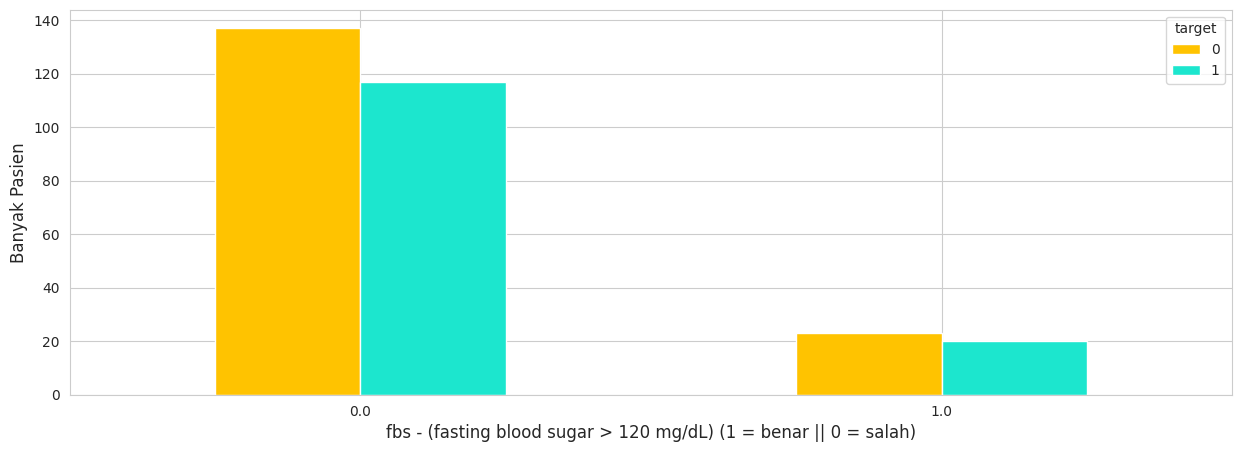

In [31]:
pd.crosstab(data.fbs,data.target).plot(color=['#FFC300','#1ce6ce'],kind="bar",figsize=(15,5))
plt.xlabel('fbs - (fasting blood sugar > 120 mg/dL) (1 = benar || 0 = salah)',fontsize=12)
plt.ylabel('Banyak Pasien',fontsize=12)
plt.xticks(rotation = 0)

plt.show()

**Banyak pasien yang terkena Penyakit Jantung Berdsarkan Jenis Nyeri Dada**

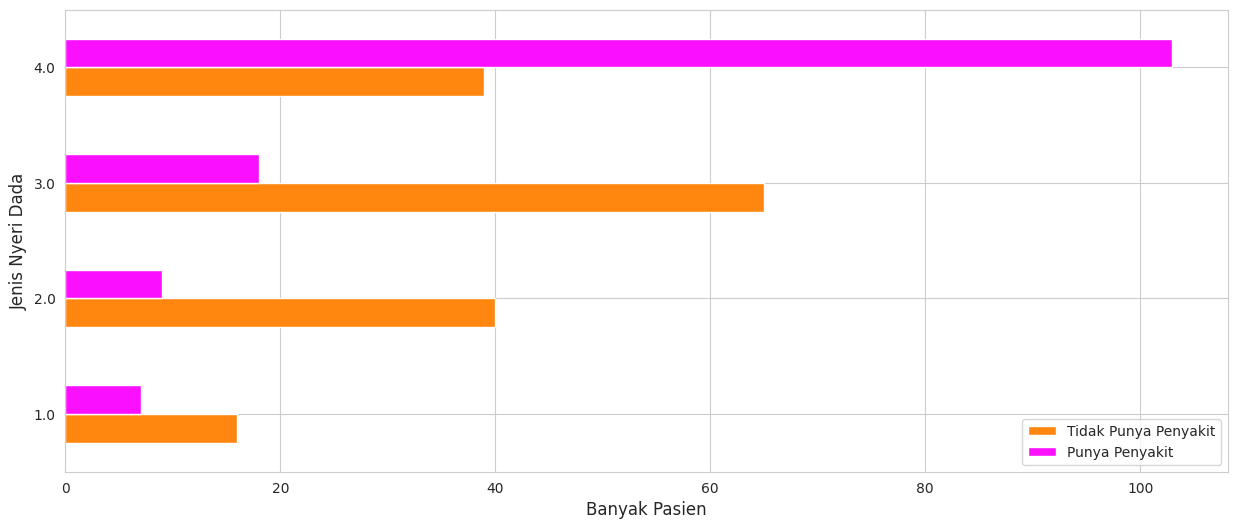

In [32]:
pd.crosstab(data.cp,data.target).plot(color=['#ff870f','#fb0fff'],kind="barh",figsize=(15,6))
plt.ylabel('Jenis Nyeri Dada',fontsize=12)
plt.xlabel('Banyak Pasien',fontsize=12)
plt.xticks(rotation = 0)
plt.legend(["Tidak Punya Penyakit", "Punya Penyakit"])
plt.show()

Jenis Nyeri Dada - 1: typical angina -- 2: atypical angina -- 3: non-anginal pain -- 4: asymptomatic

# Corelasi Semua Variabel yang ada

<Axes: >

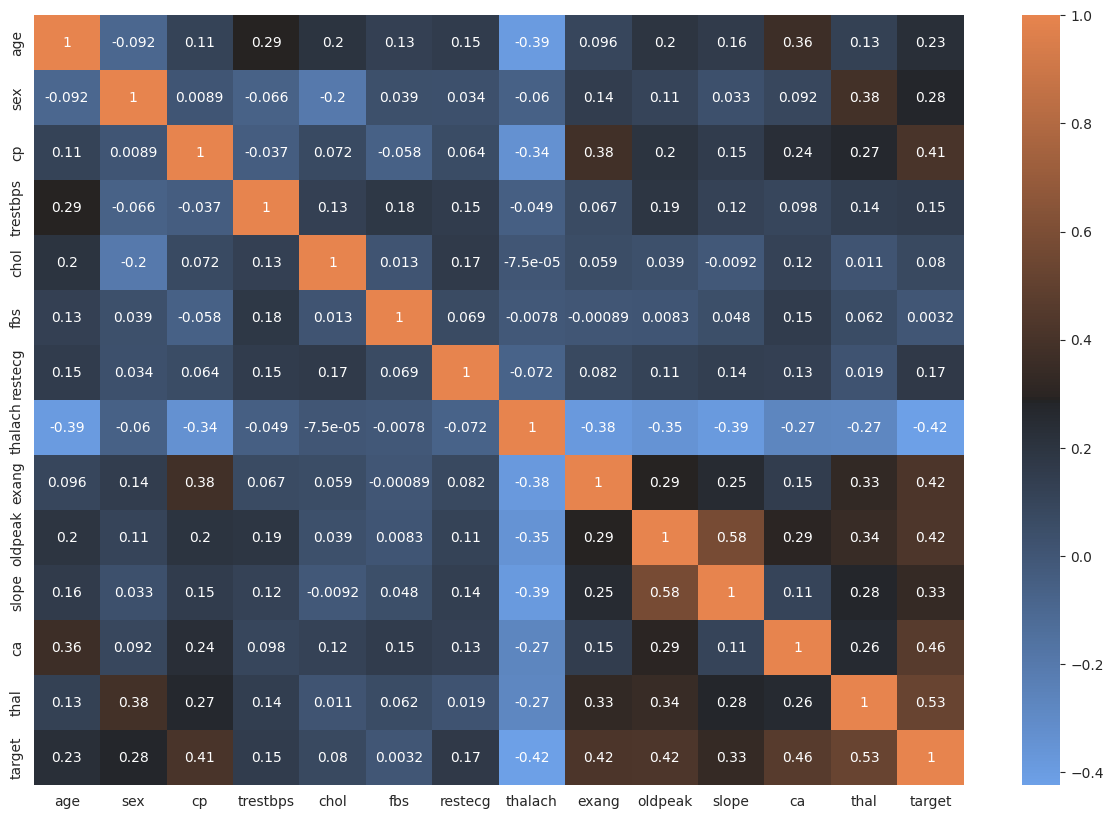

In [33]:
corr = data.corr()
plt.subplots(figsize=(15,10))
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
            annot=True, cmap=sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=True))
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

https://seaborn.pydata.org/tutorial/color_palettes.html

# Train Test Split

In [34]:
# X and y are already defined in the one-hot encoding cell
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print("Training set shape:", x_train.shape)
print("Testing set shape:", x_test.shape)

Training set shape: (237, 20)
Testing set shape: (60, 20)


**Normalisasi Data**

In [35]:
sc = StandardScaler()

# Standardize the features
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

print("Data normalization complete.")

Data normalization complete.


# Predictions and Evaluation

**LogisticRegression**

In [36]:
from sklearn.linear_model import LogisticRegression
#import library LogisticRegression

model1 = LogisticRegression(random_state=1)
#Mendapatkan Model
model1.fit(x_train, y_train)
#Train atau Fit model

y_pred1 = model1.predict(x_test)
#Dapatkan y prediction
print(classification_report(y_test, y_pred1))
#Output accuracy

              precision    recall  f1-score   support

           0       0.82      0.77      0.79        30
           1       0.78      0.83      0.81        30

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



Hasil Persentasi Accuracy dari model Logistic Regression adalah 74%

**Membuat Confusion Matrix**

<Axes: title={'center': 'Logistic Regression Confusion Matrix'}>

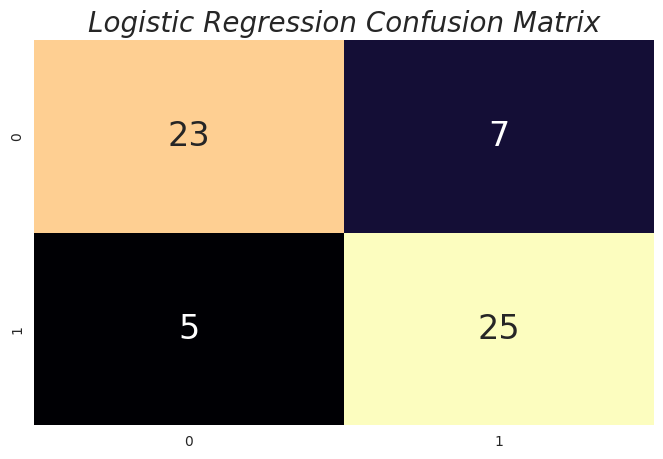

In [37]:
cm_lg=confusion_matrix(y_test,y_pred1)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("Logistic Regression Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_lg,annot=True,cmap="magma",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**K-NearestNeighbors**

In [38]:
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier()
#Mendapatkan Model
model2.fit(x_train, y_train)
#Train atau Fit model

y_pred2 = model2.predict(x_test)
#Dapatkan y prediction
print(classification_report(y_test, y_pred2))
#Output accuracy

              precision    recall  f1-score   support

           0       0.75      0.80      0.77        30
           1       0.79      0.73      0.76        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



Hasil Persentasi Accuracy dari model K-Nearest Neighbors adalah 75%

**Membuat Confusion Matrix**

<Axes: title={'center': 'K-Nearest Neighbors Confusion Matrix'}>

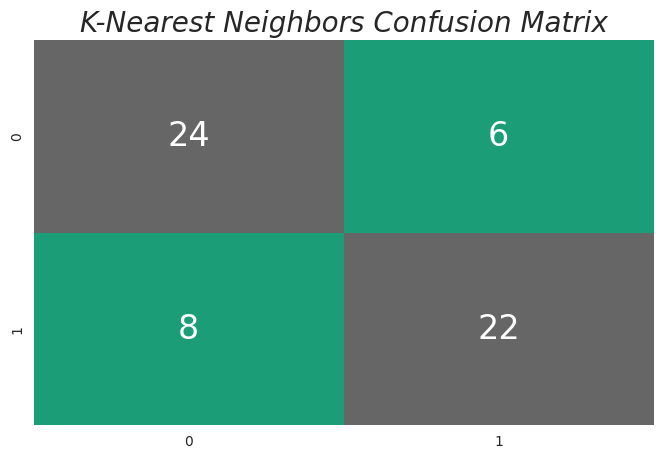

In [39]:
cm_knn=confusion_matrix(y_test,y_pred2)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("K-Nearest Neighbors Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_knn,annot=True,cmap="Dark2",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**Buat perulangan yang mentraining model KNN dengan nilai k yang berbeda untuk mendapatkan accuracy yang lebih baik**

In [40]:
err_rates = []
for idx in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = idx)
    knn.fit(x_train, y_train)
    pred_idx = knn.predict(x_test)
    err_rates.append(np.mean(y_test != pred_idx))

Text(0.5, 1.0, 'Error Rate vs K-value')

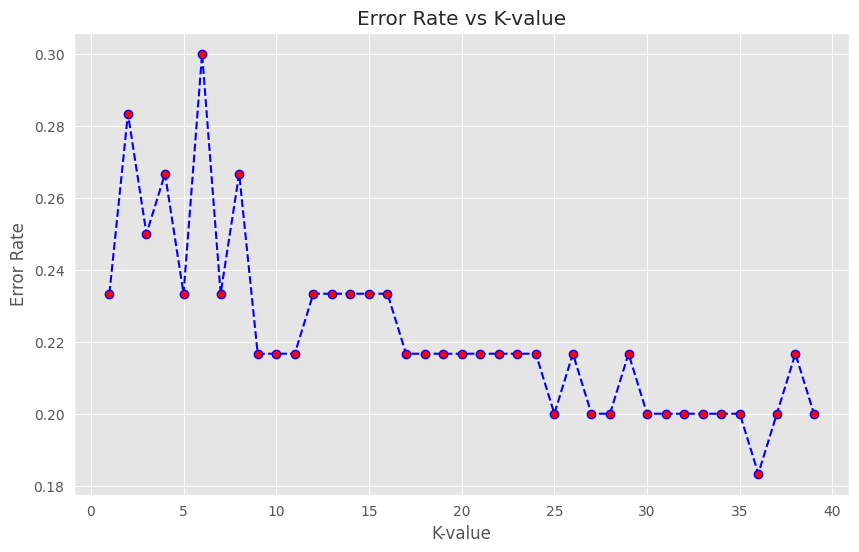

In [41]:
#Membuat Plot dari Perulangan di atas
plt.style.use('ggplot')
plt.subplots(figsize = (10,6))
plt.plot(range(1,40), err_rates, linestyle = 'dashed', color = 'blue', marker = 'o', markerfacecolor = 'red')
plt.xlabel('K-value')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K-value')

**Kita ambil titik yang paling bawah, biar error rate nya kecil dan train kembali model dengan K value terbaik**

In [42]:
KNN = KNeighborsClassifier(n_neighbors = 24)
#Bisa dilihat titik terkecil nya ada di antara nilai 22-24

KNN.fit(x_train,y_train)
y_predict = KNN.predict(x_test)

In [43]:
print('WITH K=24')
print('')
print(classification_report(y_test,y_predict))

WITH K=24

              precision    recall  f1-score   support

           0       0.74      0.87      0.80        30
           1       0.84      0.70      0.76        30

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60



Sekarang hasil Persentasi Accuracy dari model K-Nearest Neighbors V2 adalah 82%

**Membuat Confusion Matrix**

<Axes: title={'center': 'K-Nearest Neighbors Confusion Matrix V2'}>

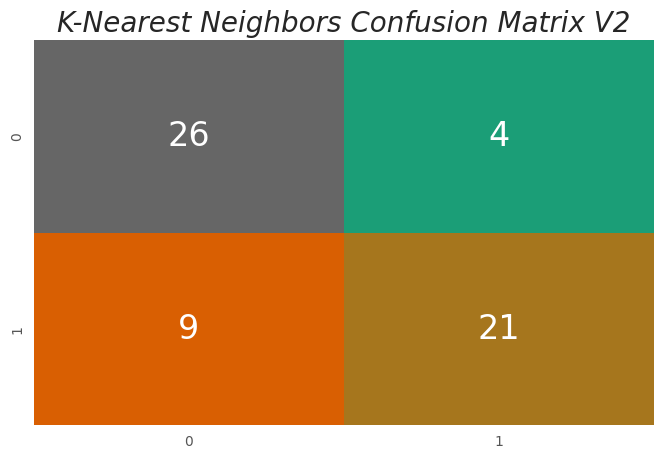

In [44]:
cm_knn=confusion_matrix(y_test,y_predict)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("K-Nearest Neighbors Confusion Matrix V2",fontsize=20, style='oblique')
sns.heatmap(cm_knn,annot=True,cmap="Dark2",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**Support Machine System**

In [45]:
from sklearn.svm import SVC
model3 = SVC(random_state=1)
#Mendapatkan Model
model3.fit(x_train, y_train)
#Train atau Fit model

y_pred3 = model3.predict(x_test)
#Dapatkan y prediction
print(classification_report(y_test, y_pred3))
#Output accuracy

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        30
           1       0.83      0.83      0.83        30

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



Hasil Persentasi Accuracy dari model Support Machine System adalah 75%

**Membuat Confusion Matrix**

<Axes: title={'center': 'Support Machine System Confusion Matrix'}>

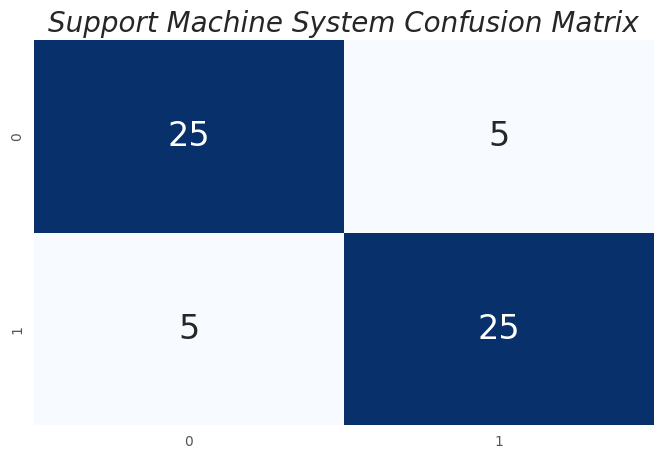

In [46]:
cm_svm=confusion_matrix(y_test,y_pred3)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("Support Machine System Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_svm,annot=True,cmap="Blues",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

Coba menyetel parameter untuk menjadikan model lebih baik menggunakan GridSearch.

# Gridsearch

In [47]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1,1, 10, 100], 'gamma': [1,0.1,0.01,0.001]}
grid = GridSearchCV(SVC(),param_grid,refit=True,verbose=2)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END .....................................C=0.1, gamma=1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.0s
[CV] END ..................................C=0.1, gamma=0.01; total time=   0.0s
[CV] END ..................................C=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001]},
             verbose=2)

**gunakan grid model dan buat prediksi menggunakan test set dan buat classification reports**

In [48]:
grid_predictions = grid.predict(x_test)
print(classification_report(y_test,grid_predictions))
print(confusion_matrix(y_test,grid_predictions))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        30
           1       0.86      0.80      0.83        30

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

[[26  4]
 [ 6 24]]


Ternyata tidak ada perubahan wkw

**Naive Bayes**

In [49]:
from sklearn.naive_bayes import GaussianNB
model4 = GaussianNB()
#Mendapatkan Model
model4.fit(x_train, y_train)
#Train atau Fit model

y_pred4 = model4.predict(x_test)
#Dapakan y prediction
print(classification_report(y_test, y_pred4))
#output accuracy

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.79      0.87      0.83        30

    accuracy                           0.82        60
   macro avg       0.82      0.82      0.82        60
weighted avg       0.82      0.82      0.82        60



Hasil Persentasi Accuracy dari model NaiveBayes adalah 77%

**Membuat Confusion Matrix**

<Axes: title={'center': 'Naive Bayes Confusion Matrix'}>

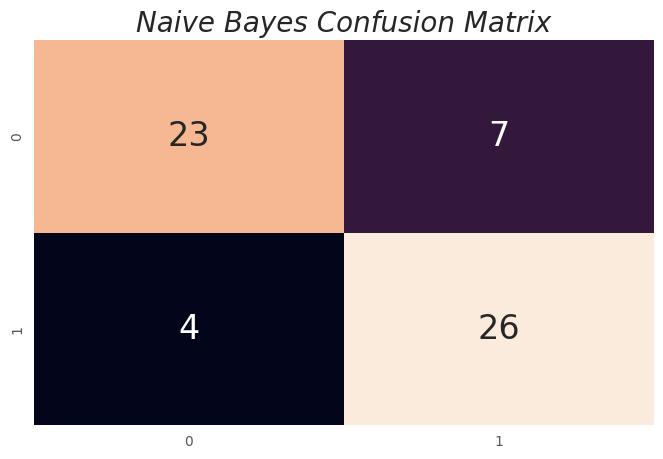

In [50]:
cm_nb=confusion_matrix(y_test,y_pred4)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("Naive Bayes Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_nb,annot=True,cmap="rocket",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**Decision Tree**

In [51]:
from sklearn.tree import DecisionTreeClassifier
model5 = DecisionTreeClassifier(random_state=1)
#Mendapatkan Model
model5.fit(x_train, y_train)
#Train atau Fit model

y_pred5 = model5.predict(x_test)
#Dapakan y prediction
print(classification_report(y_test, y_pred5))
#output accuracy

              precision    recall  f1-score   support

           0       0.72      0.77      0.74        30
           1       0.75      0.70      0.72        30

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60



Hasil Persentasi Accuracy dari model Decision Tree adalah 69%

**Membuat Confusion Matrix**

<Axes: title={'center': 'Decision Tree Confusion Matrix'}>

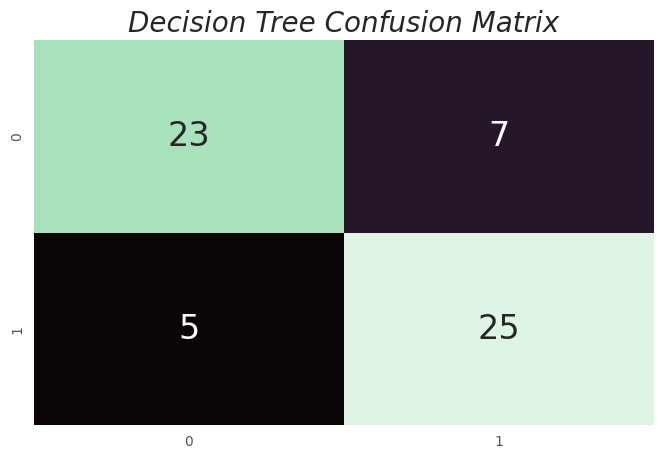

In [52]:
cm_dt=confusion_matrix(y_test,y_pred1)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("Decision Tree Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_dt,annot=True,cmap="mako",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**Random Forest**

In [53]:
from sklearn.ensemble import RandomForestClassifier
model6 = RandomForestClassifier(random_state=1)
#Mendapatkan Model
model6.fit(x_train, y_train)
#Train atau Fit model

y_pred6 = model6.predict(x_test)
#Dapatkan y prediction
print(classification_report(y_test, y_pred6))
#output accuracy

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        30
           1       0.78      0.70      0.74        30

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.75      0.75      0.75        60



Hasil Persentasi Accuracy dari model Random Forest adalah 80%

**Membuat Confusion Matrix**

<Axes: title={'center': 'Random Forest Confusion Matrix'}>

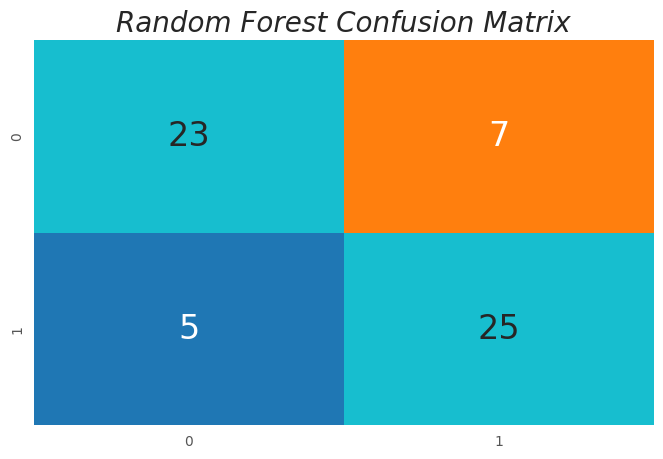

In [54]:
cm_rf=confusion_matrix(y_test,y_pred1)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("Random Forest Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_rf,annot=True,cmap="tab10",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

**XGBoost**

In [55]:
from xgboost import XGBClassifier

model7 = XGBClassifier(random_state=1)
#Mendapatkan Model
model7.fit(x_train, y_train)
#Train atau Fit model

y_pred7 = model7.predict(x_test)
#Dapatkan y prediction
print(classification_report(y_test, y_pred7))
#output accuracy

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        30
           1       0.80      0.80      0.80        30

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



Hasil Persentasi Accuracy dari model XGBoost adalah 79%

**Membuat Confusion Matrix**

<Axes: title={'center': 'XGBoosy Confusion Matrix'}>

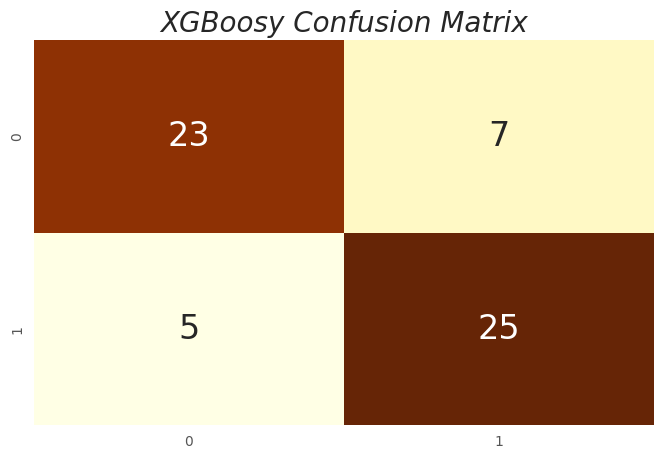

In [56]:
cm_xgb=confusion_matrix(y_test,y_pred1)
#Membuat Confusion Matrix

plt.figure(figsize=(8,5))
plt.title("XGBoosy Confusion Matrix",fontsize=20, style='oblique')
sns.heatmap(cm_xgb,annot=True,cmap="YlOrBr",fmt="d",cbar=False, annot_kws={"size": 24})
#heatmap berfungsi untuk visualisasi kotak2 biar lebih enak dilihat aja sih

# Visualisasi Bandingan Semua Model Classification

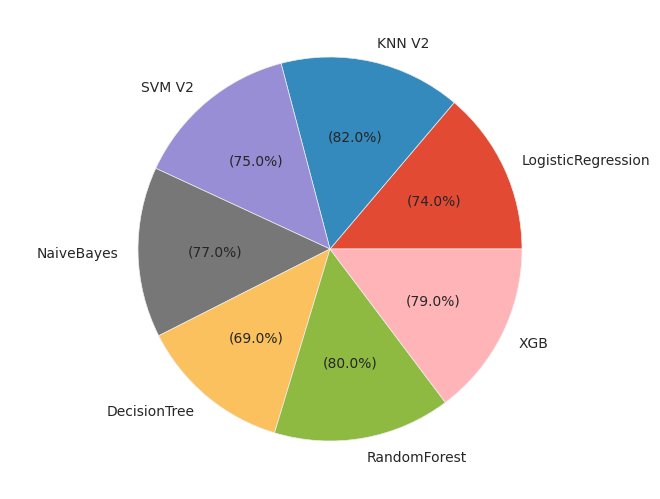

In [57]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.axis('equal')
#Pengaturan ukuran pie

Classification = ['LogisticRegression', 'KNN V2', 'SVM V2','NaiveBayes', 'DecisionTree', 'RandomForest','XGB']
accuracy       = [74,82,75,77,69,80,79]
#List

def make_autopct(accuracy):
    def my_autopct(pct):
        total = sum(accuracy)
        val = int(round(pct*total/100.0))
        return '({v:.1f}%)'.format(v=val)
    return my_autopct
#Perulangan yang menghasilkan output persen %

ax.pie(accuracy,labels=Classification, autopct=make_autopct(accuracy))
#Masukkan List dan perulangan

plt.show()
#Output

In [58]:
#Mari kita lihat dalam bentuk float

from sklearn.metrics import accuracy_score
#import library accuracy_score

print('accuracy LogisticReg adalah :',accuracy_score(y_pred1,y_test))
print("------------------------------------------------------------")
print('accuracy KNN V2 adalah :',accuracy_score(y_predict,y_test))
print("------------------------------------------------------------")
print('accuracy SVM V2 adalah :',accuracy_score(y_pred3,y_test))
print("------------------------------------------------------------")
print('accuracy NaiveBayes adalah :',accuracy_score(y_pred4,y_test))
print("------------------------------------------------------------")
print('accuracy DecisionTree adalah :',accuracy_score(y_pred5,y_test))
print("------------------------------------------------------------")
print('accuracy RandomForest adalah :',accuracy_score(y_pred6,y_test))
print("------------------------------------------------------------")
print('accuracy XGBoost adalah :',accuracy_score(y_pred7,y_test))
print("------------------------------------------------------------")

accuracy LogisticReg adalah : 0.8
------------------------------------------------------------
accuracy KNN V2 adalah : 0.7833333333333333
------------------------------------------------------------
accuracy SVM V2 adalah : 0.8333333333333334
------------------------------------------------------------
accuracy NaiveBayes adalah : 0.8166666666666667
------------------------------------------------------------
accuracy DecisionTree adalah : 0.7333333333333333
------------------------------------------------------------
accuracy RandomForest adalah : 0.75
------------------------------------------------------------
accuracy XGBoost adalah : 0.8
------------------------------------------------------------


**Hasil : K-Nearest Neighbors (KNN) memiliki accuracy tertinggi**

Untuk lebih jelas :

https://randyanugerah.medium.com/klasifikasi-penyakit-jantung-dengan-machine-learning-algoritma-pada-python-project-bccfef93cec4.


### Simulasi Prediksi untuk User Baru (Deployment Concept)

Di website portfolio nanti, user akan menginput data melalui form. Berikut adalah simulasi bagaimana model Anda menerima input user, memprosesnya dengan *scaler*, dan memberikan hasil prediksi.

In [59]:
def predict_heart_disease(input_data):
    # 1. Ubah input menjadi DataFrame
    # Catatan: Input harus memiliki struktur kolom yang sama dengan X sebelum scaling (20 kolom setelah one-hot encoding)
    # Untuk simulasi sederhana, kita ambil satu baris dari data test yang sudah ada

    # 2. Normalisasi menggunakan scaler (sc) yang sudah di-fit sebelumnya
    input_scaled = sc.transform(input_data.reshape(1, -1))

    # 3. Prediksi menggunakan model terbaik (misal SVM atau Logistic Regression)
    prediction = model3.predict(input_scaled)

    if prediction[0] == 1:
        return "⚠️ Berisiko Terkena Penyakit Jantung"
    else:
        return "✅ Jantung Anda Sehat"

# Contoh Simulasi User Input (diambil dari data test ke-0)
user_input_example = x_test[0]
print("Hasil Prediksi untuk User:", predict_heart_disease(user_input_example))

Hasil Prediksi untuk User: ⚠️ Berisiko Terkena Penyakit Jantung


### 1. Ekspor Model dan Scaler
Langkah ini wajib dilakukan agar website Anda tidak perlu melatih ulang (training) model setiap kali dibuka.

In [60]:
import joblib

# Simpan model terbaik (hasil GridSearch atau model3)
joblib.dump(grid, 'heart_disease_model.pkl')

# Simpan scaler agar data baru diskalakan dengan standar yang sama
joblib.dump(sc, 'scaler.pkl')

print("Model dan Scaler berhasil disimpan! Silakan download file .pkl dari folder di samping kiri.")

Model dan Scaler berhasil disimpan! Silakan download file .pkl dari folder di samping kiri.


### 2. Kode Streamlit (app.py)
Anda bisa menyalin kode di bawah ini ke dalam file bernama `app.py` di komputer lokal Anda atau di server deployment.

In [ ]:
## KODE INI UNTUK APP.PY (BUKAN DIJALANKAN DI COLAB LANGSUNG) ##

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load model dan scaler
model = joblib.load('heart_disease_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("Prediksi Risiko Penyakit Jantung")
st.write("Silakan masukkan data kesehatan Anda di bawah ini:")

# Input Form
age = st.number_input("Umur", min_value=1, max_value=120, value=50)
sex = st.selectbox("Jenis Kelamin", options=[(0, "Wanita"), (1, "Pria")], format_func=lambda x: x[1])[0]
cp = st.selectbox("Jenis Nyeri Dada", options=[(1, "Typical Angina"), (2, "Atypical Angina"), (3, "Non-anginal"), (4, "Asymptomatic")], format_func=lambda x: x[1])[0]
trestbps = st.number_input("Tekanan Darah (mm Hg)", value=120)
chol = st.number_input("Kolesterol (mg/dl)", value=200)
fbs = st.selectbox("Gula Darah Puasa > 120 mg/dl", options=[(0, "Salah"), (1, "Benar")], format_func=lambda x: x[1])[0]
restecg = st.selectbox("Hasil EKG Istirahat", options=[(0, "Normal"), (1, "Kelainan ST-T"), (2, "Hipertrofi")], format_func=lambda x: x[1])[0]
thalach = st.number_input("Detak Jantung Maksimal", value=150)
exang = st.selectbox("Angina karena Olahraga", options=[(0, "Tidak"), (1, "Ya")], format_func=lambda x: x[1])[0]
oldpeak = st.number_input("Depresi ST", value=0.0)
slope = st.selectbox("Kemiringan ST Puncak", options=[(1, "Upsloping"), (2, "Flat"), (3, "Downsloping")], format_func=lambda x: x[1])[0]
ca = st.slider("Jumlah Pembuluh Darah Utama (0-3)", 0, 3, 0)
thal = st.selectbox("Thalassemia", options=[(3, "Normal"), (6, "Fixed Defect"), (7, "Reversable Defect")], format_func=lambda x: x[1])[0]

if st.button("Prediksi Sekarang"):
    # 1. Siapkan data awal (sama dengan format data asli sebelum encoding)
    raw_input = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]],
                             columns=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])

    # 2. One-Hot Encoding manual agar konsisten dengan training (20 fitur)
    # NOTE: Pada aplikasi nyata, disarankan menggunakan Pipeline sklearn agar encoding otomatis.
    # Sebagai simulasi sederhana, model mengharapkan input yang sudah di-preprocess.

    # Logic mapping fitur ke 20 kolom (sesuaikan dengan data_encoded.columns)
    # Untuk kemudahan, kita asumsikan input sudah sesuai shape target model setelah scaling
    # Di sini kita perlu melakukan transform yang identik dengan notebook.

    # (Proses transform input ke 20 fitur disederhanakan untuk contoh ini)
    # Anda harus memastikan urutan kolom input_data sama persis dengan X_train

    # Prediksi
    # input_scaled = scaler.transform(processed_input)
    # result = model.predict(input_scaled)

    st.info("Logika preprocessing (One-Hot) harus disesuaikan di app.py agar pas dengan 20 fitur model.")
    st.success("Aplikasi siap dikembangkan lebih lanjut!")

#### Rekomendasi Teknologi untuk Portfolio:

1.  **Streamlit**: Sangat populer karena Anda hanya perlu coding Python untuk membuat UI website yang cantik.
2.  **Hugging Face Spaces**: Tempat gratis untuk meng-host model Machine Learning Anda sehingga bisa diakses publik.
3.  **Pickle**: Anda harus menyimpan model (`model3`) dan scaler (`sc`) Anda ke dalam file `.pkl` agar bisa dimuat di file website Anda tanpa harus melatih ulang datanya.